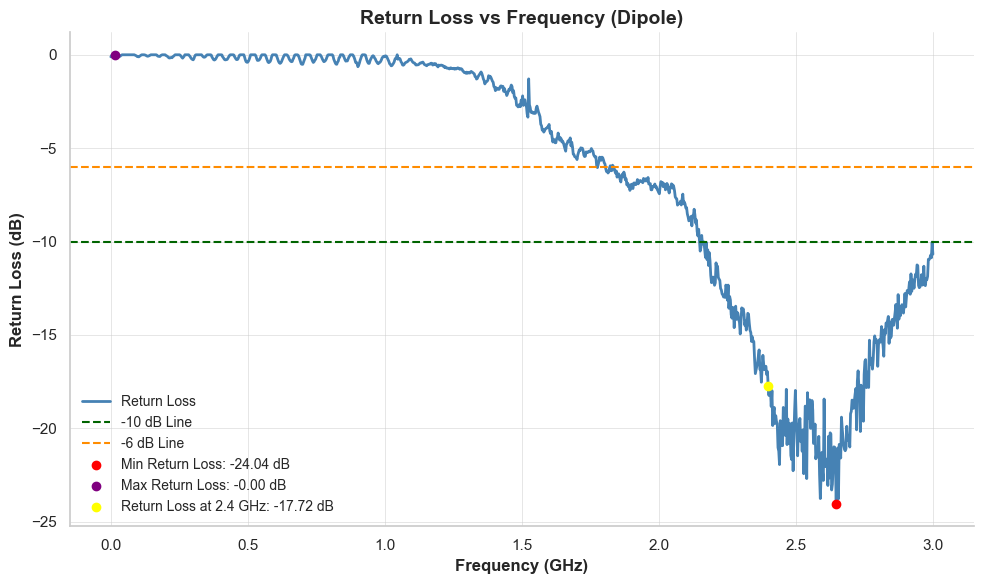

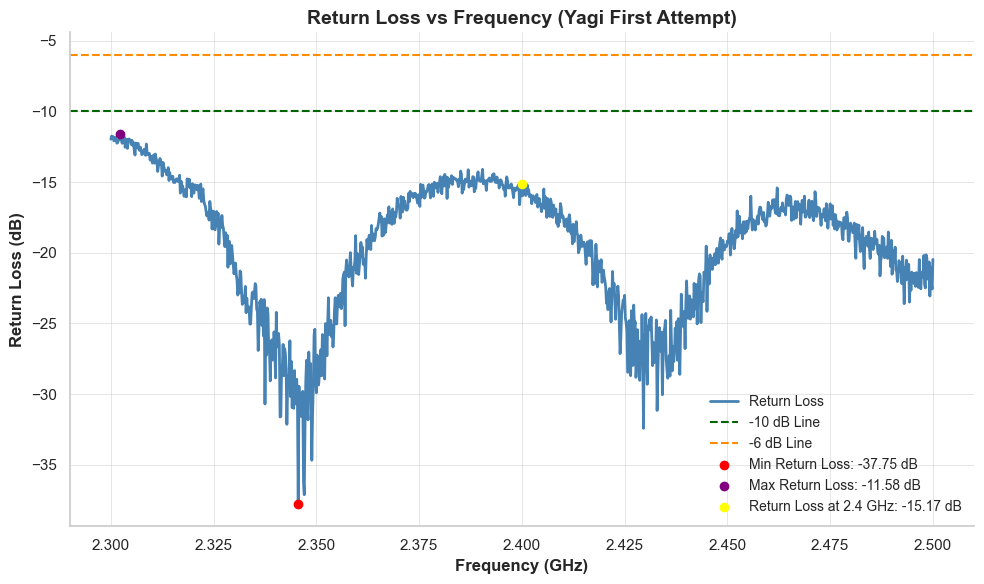

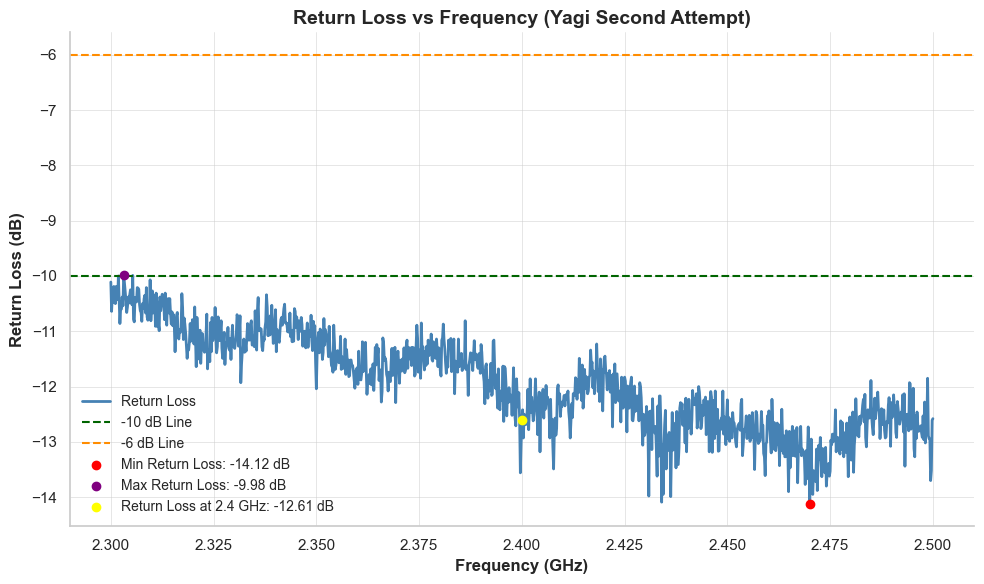

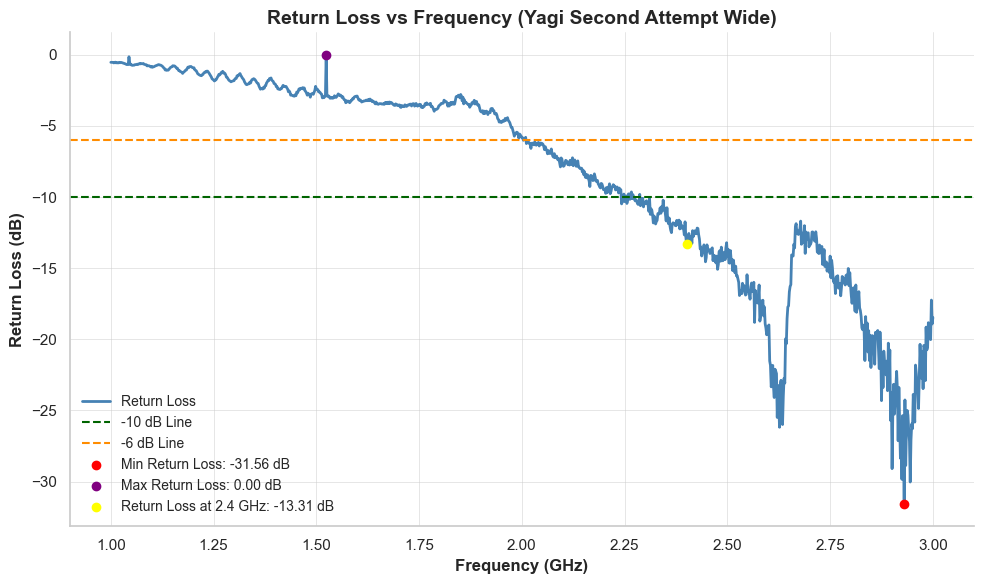

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style="whitegrid", palette="muted")

# Load Excel file with multiple sheets
excel_file = 'excel_plots.xlsx'  # Change this to the path of your Excel file
df = pd.read_excel(excel_file, sheet_name=None)

# Create a plot for each sheet in the Excel file
for sheet_name, data in df.items():
    # Ensure the necessary columns are present in the sheet
    if 'Frequency(Hz)' in data.columns and 'Return Loss(dB)' in data.columns:
        # Convert Frequency to GHz for the plot
        data["Return Loss(dB)"] = data["Return Loss(dB)"].astype(str).str.replace(",", ".").astype(float)
        data['Frequency(GHz)'] = data['Frequency(Hz)'] / 1e9
        
        # Find minimum and maximum return loss points
        min_return_loss_idx = data['Return Loss(dB)'].idxmin()
        min_return_loss_freq = data['Frequency(GHz)'][min_return_loss_idx]
        min_return_loss_value = data['Return Loss(dB)'][min_return_loss_idx]
        
        max_return_loss_idx = data['Return Loss(dB)'].idxmax()
        max_return_loss_freq = data['Frequency(GHz)'][max_return_loss_idx]
        max_return_loss_value = data['Return Loss(dB)'][max_return_loss_idx]
        
        # Find the closest frequency to 2.4 GHz
        target_freq = 2.4  # GHz
        closest_freq_idx = (data['Frequency(GHz)'] - target_freq).abs().idxmin()
        closest_freq = data['Frequency(GHz)'][closest_freq_idx]
        closest_return_loss = data['Return Loss(dB)'][closest_freq_idx]
        
        # Create a figure and axis
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Plot the Return Loss vs frequency
        ax.plot(data['Frequency(GHz)'], data['Return Loss(dB)'], label='Return Loss', color='steelblue', linewidth=2)
        
        # Draw horizontal lines at -10 dB and -6 dB
        ax.axhline(y=-10, color='darkgreen', linestyle='--', label='-10 dB Line', linewidth=1.5)
        ax.axhline(y=-6, color='darkorange', linestyle='--', label='-6 dB Line', linewidth=1.5)
        
        # Mark the minimum and maximum Return Loss points
        ax.scatter(min_return_loss_freq, min_return_loss_value, color='red', label=f'Min Return Loss: {min_return_loss_value:.2f} dB', zorder=5)
        ax.scatter(max_return_loss_freq, max_return_loss_value, color='purple', label=f'Max Return Loss: {max_return_loss_value:.2f} dB', zorder=5)
        
        
        # Mark the closest point to 2.4 GHz
        ax.scatter(closest_freq, closest_return_loss, color='yellow', label=f'Return Loss at 2.4 GHz: {closest_return_loss:.2f} dB', zorder=5)
        
        # Add labels, title, and legend with styling
        ax.set_xlabel('Frequency (GHz)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Return Loss (dB)', fontsize=12, fontweight='bold')
        ax.set_title(f'Return Loss vs Frequency ({sheet_name})', fontsize=14, fontweight='bold')
        
        # Improve legend
        ax.legend(loc='best', fontsize=10, frameon=False, title=None, title_fontsize='13', shadow=True)
        
        # Enhance grid and remove spines for cleaner look
        ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
        sns.despine()  # This will remove the top and right spines for a cleaner look
        
        # Show plot
        plt.tight_layout()  # To ensure the labels don't overlap
        plt.show()
    else:
        print(f"Sheet '{sheet_name}' does not contain required columns.")
